In [1]:
import datasets as hfds
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

In [2]:
plt.rcParams["figure.dpi"] = 150

In [3]:
dataset_dict = hfds.load_from_disk("../datasets/nsd_flat_cococlip")
mask = np.load("../metadata/nsd_flat_mask.npy")
print(f"mask: {mask.shape}, {mask.sum()} voxels")

mask: (215, 200), 18577 voxels


In [4]:
# Extract masked training data
activity = np.array(dataset_dict["train"]["activity"])  # (N, 215, 200) or (N, 1, 215, 200)
if activity.ndim == 4:
    activity = activity[:, 0]
X_train = activity[:, mask]  # (N, 18577)
print(f"X_train: {X_train.shape}, dtype: {X_train.dtype}")

# Per-sample z-normalize (matching training scripts)
mean = X_train.mean(axis=1, keepdims=True)
std = X_train.std(axis=1, keepdims=True)
std = np.clip(std, 1e-6, None)
X_train = (X_train - mean) / std
print(f"After z-norm: mean={X_train.mean():.4f}, std={X_train.std():.4f}")

X_train: (32539, 18577), dtype: uint8
After z-norm: mean=0.0000, std=1.0000


In [5]:
# Fit PCA with 512 components
n_components = 512
pca = PCA(n_components=n_components, svd_solver="randomized")
pca.fit(X_train)
print(f"Explained variance (total): {pca.explained_variance_ratio_.sum():.4f}")
print(f"Components shape: {pca.components_.shape}")

Explained variance (total): 0.6915
Components shape: (512, 18577)


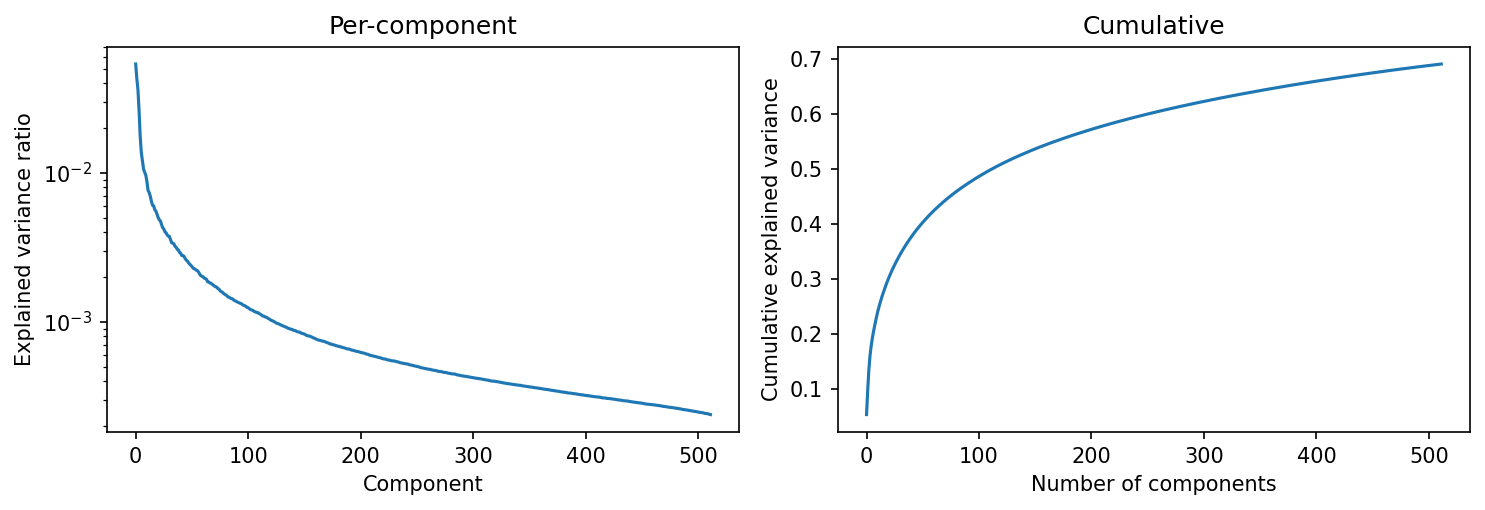

In [6]:
# Plot explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.plot(pca.explained_variance_ratio_)
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Per-component")
ax1.set_yscale("log")

ax2.plot(cumvar)
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Cumulative")
for thresh in [0.8, 0.9, 0.95, 0.99]:
    idx = np.searchsorted(cumvar, thresh)
    if idx < len(cumvar):
        ax2.axhline(thresh, color="gray", ls="--", lw=0.5)
        ax2.annotate(f"{thresh:.0%} @ {idx + 1}", (idx + 1, thresh), fontsize=7)

plt.tight_layout()

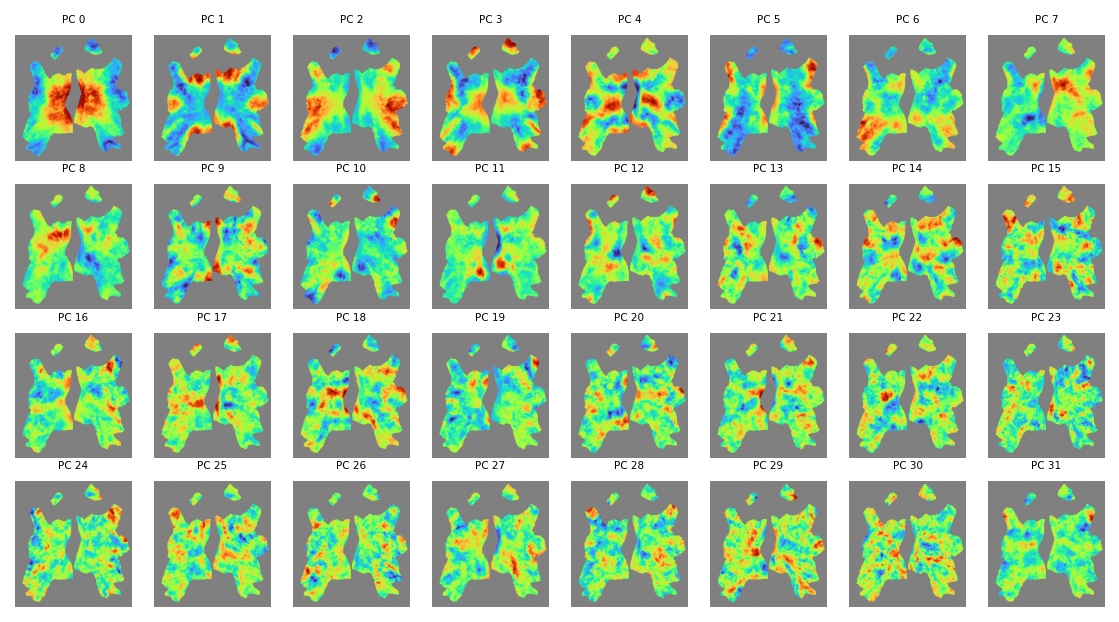

In [8]:
# Plot first 32 PCA components on the flat map
H, W = mask.shape
ploth = 1.0
plotw = (W / H) * ploth
nr = 4
nc = 8
f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth))
axs = axs.flatten()

cmap = plt.get_cmap("turbo")
cmap.set_bad("gray")

for ii, ax in enumerate(axs):
    comp = np.full((H, W), np.nan)
    comp[mask] = pca.components_[ii]
    plt.sca(ax)
    plt.imshow(comp, cmap=cmap)
    plt.axis("off")
    plt.title(f"PC {ii}", fontsize=5)

plt.tight_layout(pad=0.2)

In [7]:
# Save PCA artifacts
# components: (512, 18577) — projection matrix
# mean: (18577,) — feature mean for centering
# scale: (512,) — std of each PC (sqrt of explained_variance) for whitening
np.savez(
    "../metadata/nsd_flat_pca.npz",
    components=pca.components_.astype(np.float32),
    mean=pca.mean_.astype(np.float32),
    scale=np.sqrt(pca.explained_variance_).astype(np.float32),
)
print("Saved to metadata/nsd_flat_pca.npz")
print(f"  components: {pca.components_.shape}")
print(f"  mean: {pca.mean_.shape}")
print(f"  scale: {np.sqrt(pca.explained_variance_).shape}")

Saved to metadata/nsd_flat_pca.npz
  components: (512, 18577)
  mean: (18577,)
  scale: (512,)
